# Masterclass: Arquitetura de Risco de Crédito (V15 - Novas APIs)
Demonstração prática das novas APIs simplificadas, integração de rating na CreditPolicy e RateStage flexível.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pycreditools import (
    CreditPolicy,
    CustomStress,
    ModelEvaluator,
    TradeoffAnalyzer,  # Importado para compatibilidade com o crash test
    col,
    fit_risk_groups,
    optimize_cutoffs,
    fit_pairwise_risk_groups,
    GroupingRecipe,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

## 1. Geração da Base e Panorama Vigente
A política legada usa `legacy_score` e aprova ~22% do Top of Funnel.


In [2]:
def gerar_base(n=1_000_000):
    rng = np.random.default_rng(42)
    regions  = ["Sudeste","Sul","Nordeste","Centro-Oeste","Norte"]
    r_probs  = [0.45, 0.20, 0.18, 0.10, 0.07]
    r_bias   = {"Sudeste": -0.2, "Sul": -0.3, "Nordeste": 0.25, "Centro-Oeste": 0.05, "Norte": 0.3}
    vintages = pd.date_range("2024-01-01", periods=18, freq="MS").strftime("%Y-%m").tolist()
    v_pen   = {v: (i/17)*0.3 for i, v in enumerate(vintages)}

    df = pd.DataFrame({
        "applicant_id": range(1, n+1),
        "safra":  rng.choice(vintages, n),
        "region": rng.choice(regions, n, p=r_probs),
        "age":    rng.normal(38, 14, n).clip(16, 90).astype(int),
        "income": rng.lognormal(7.8, 0.6, n).astype(int),
        "employment": rng.choice(["Assalariado","Autônomo","Empresário","Desempregado"],
                                  n, p=[0.60,0.25,0.10,0.05]),
    })
    df["cpf_valido"]     = rng.choice([True,False], n, p=[0.998,0.002])
    df["vl_negativacao"] = rng.choice([0,1],n,p=[0.78,0.22]) * rng.lognormal(7.0,1.5,n).astype(int)
    df["vl_vencido_scr"] = rng.choice([0,1],n,p=[0.83,0.17]) * rng.lognormal(7.5,1.8,n).astype(int)
    df["vl_protestos"]   = rng.choice([0,1],n,p=[0.89,0.11]) * rng.lognormal(6.5,1.2,n).astype(int)

    # Latent high-variance risk factor u ~ N(0, 3.0)
    u = rng.normal(0, 3.0, n)
    
    y = (
        -2.5
        + df["region"].map(r_bias).astype(float)
        + (df["age"] < 25).astype(float)                * 1.0
        + (~df["cpf_valido"]).astype(float)              * 4.0
        + (df["income"] < 2000).astype(float)            * 0.5
        + (df["employment"]=="Desempregado").astype(float)* 1.2
        + (df["vl_negativacao"] >    0).astype(float)   * 1.2
        + (df["vl_negativacao"] > 2000).astype(float)   * 1.5
        + (df["vl_vencido_scr"] >    0).astype(float)   * 1.0
        + (df["vl_vencido_scr"] > 3000).astype(float)   * 1.8
        + (df["vl_protestos"]   >    0).astype(float)   * 1.5
        + (df["vl_protestos"]   >  500).astype(float)   * 2.0
        + df["safra"].map(v_pen).astype(float)
        + u
    )

    df["true_pd"]        = 1.0 / (1.0 + np.exp(-y))
    df["actual_default"] = (rng.random(n) < df["true_pd"]).astype(int)

    def norm_cdf(x):
        return 1.0 / (1.0 + np.exp(-1.702 * x))

    s = -y

    # Shared noise to simulate high correlation between legacy/candidate models
    c_noise = rng.normal(0, 2.5, n)

    # Calibrated independent noise settings to hit targets: Legacy KS ~25%, Score_5 KS ~31% (Delta ~5.8%)
    legacy_noise = 1.30
    noises_candidates = {
        "score_2": 1.25,
        "score_3": 1.10,
        "score_4": 0.95,
        "score_5": 0.80,
    }

    # Legacy Score
    legacy_latent = s + c_noise + rng.normal(0, legacy_noise, n)
    z_legacy = (legacy_latent - legacy_latent.mean()) / legacy_latent.std()
    df["legacy_score"] = np.round(norm_cdf(z_legacy) * 1000).astype(int)

    # Candidate Scores
    for name, noise_std in noises_candidates.items():
        latent = s + c_noise + rng.normal(0, noise_std, n)
        z = (latent - latent.mean()) / latent.std()
        df[name] = np.round(norm_cdf(z) * 1000).astype(int)

    # Política histórica: top 22% do legacy_score
    df["approved"] = 1
    df.loc[(df["age"] < 18) | (df["vl_negativacao"] > 5000), "approved"] = 0
    legacy_cut = float(df["legacy_score"].quantile(0.78))
    df.loc[df["legacy_score"] < legacy_cut, "approved"] = 0

    df["score_decile"] = pd.qcut(df["score_5"], q=10, labels=False, duplicates="drop")
    df["take_up_rate"] = 0.95 - df["score_decile"] * 0.06
    df["hired"]        = df["approved"] * (rng.random(n) < df["take_up_rate"]).astype(int)
    df["sample"]       = np.where(df["safra"].str.startswith("2024"), "DEV", "OOT")
    return df, legacy_cut



In [3]:
df, LEGACY_CUT = gerar_base(1_000_000)
df_hist = df[df["hired"] == 1].copy()
df_dev  = df[df["sample"] == "DEV"].copy()

N         = len(df)
n_aprov   = int(df["approved"].sum())
n_hired   = int(df["hired"].sum())
bad_hired = df_hist["actual_default"].mean()

print("=== PANORAMA ATUAL (POLÍTICA LEGADA) ===")
print(f"Top of Funnel:                  {N:>10,}")
print(f"Aprovados (Legacy Score p78):   {n_aprov:>10,}  ({n_aprov/N:.1%} do funil)")
print(f"Contratados (após take-up):     {n_hired:>10,}  ({n_hired/n_aprov:.1%} dos aprovados)")
print(f"Bad Rate Contratados (P&L):     {bad_hired:>10.2%}   ← ALVO")
print(f"Legacy Score Cutoff (p78):      {LEGACY_CUT:>10,.0f}")



=== PANORAMA ATUAL (POLÍTICA LEGADA) ===
Top of Funnel:                   1,000,000
Aprovados (Legacy Score p78):      204,746  (20.5% do funil)
Contratados (após take-up):         94,675  (46.2% dos aprovados)
Bad Rate Contratados (P&L):          7.18%   ← ALVO
Legacy Score Cutoff (p78):             789


## 2. Poder Preditivo: KS na Carteira Vigente
A capacidade discriminatória de cada score **dentro da carteira contratada**.


In [4]:
all_scores = [f"score_{i}" for i in range(2,6)] + ["legacy_score"]
ev = ModelEvaluator(df_hist, all_scores, "actual_default")
ks = ev.compute_ks()

ks_df = (pd.DataFrame(list(ks.items()), columns=["Modelo","KS"])
           .sort_values("KS", ascending=False).reset_index(drop=True))
ks_df["KS (%)"] = ks_df["KS"].apply(lambda x: f"{x*100:.1f}")
ks_df["Power"]  = ks_df["KS"].apply(
    lambda x: "🔴 Fraco" if x<0.20 else ("🟡 Razoável" if x<0.30 else
              ("🟢 Bom" if x<0.45 else "🏆 Excelente")))
print("=== PODER PREDITIVO (KS NA CARTEIRA HISTÓRICA) ===")
print(ks_df[["Modelo","KS (%)","Power"]].to_string(index=False))

print("\n=== TABELA DECIL DO SCORE CAMPEÃO (SCORE 5) ===")
t = ev.compute_ks_table("score_5", bins=10)
print(t.map(lambda x: f"{x:.3f}" if isinstance(x,float) else x).to_string(index=False))



=== PODER PREDITIVO (KS NA CARTEIRA HISTÓRICA) ===
      Modelo KS (%)      Power
     score_5   31.6      🟢 Bom
     score_4   30.7      🟢 Bom
     score_3   30.3      🟢 Bom
     score_2   29.2 🟡 Razoável
legacy_score   25.8 🟡 Razoável

=== TABELA DECIL DO SCORE CAMPEÃO (SCORE 5) ===
 Bucket Avg_Score  Volume Bad_Rate Cum_Bads Cum_Goods    KS
      1   978.707    9151    0.006    0.009     0.103 0.095
      2   953.421    9740    0.019    0.036     0.212 0.177
      3   930.595    9250    0.030    0.077     0.314 0.237
      4   908.020    9347    0.039    0.130     0.417 0.286
      5   885.698    9515    0.056    0.209     0.519 0.310
      6   861.820    9614    0.069    0.306     0.621 0.314
      7   833.215    9478    0.086    0.426     0.719 0.294
      8   797.597    9454    0.099    0.563     0.816 0.253
      9   750.061    9602    0.125    0.740     0.912 0.172
     10   643.203    9524    0.186    1.000     1.000 0.000


## 3. Escudos de Bureau e o Funil de Qualidade
O custo de cada etapa de filtro de bureau, incluindo o filtro de cutoff do score legado.


In [5]:
score_cols = [f"score_{i}" for i in range(2,6)]
base_policy = CreditPolicy(
    applicant_id_col="applicant_id", score_cols=score_cols,
    current_approval_col="approved",  actual_default_col="actual_default",
    time_col="safra"
)
policy_hf = (
    base_policy
    .filter("CPF Válido",       col("cpf_valido") == True)
    .filter("Teto Negativação",  col("vl_negativacao") <= 1500)
    .filter("Teto Atraso SCR",   col("vl_vencido_scr") <= 3000)
    .filter("Teto Protestos",    col("vl_protestos") <= 500)
)

policy_legacy_hf = (
    policy_hf
    .filter("Ponto de Corte Vigente", col("legacy_score") >= LEGACY_CUT)
)

# Build monotonic funnel sequence including the legacy score cutoff
masks = {
    "Top of Funnel":               pd.Series(True, index=df_dev.index),
    "Após CPF Válido":             df_dev["cpf_valido"] == True,
    "Após Teto Negativação":       df_dev["vl_negativacao"] <= 1500,
    "Após Teto SCR":               df_dev["vl_vencido_scr"] <= 3000,
    "Após Teto Protestos":         df_dev["vl_protestos"] <= 500,
    "Após Ponto de Corte Vigente": df_dev["legacy_score"] >= LEGACY_CUT,
}

cumulativo = pd.Series(True, index=df_dev.index)
print("=== FUNIL DE APROVAÇÃO (BASE DEV) ===")
print(f"{'Etapa':<28} {'Volume':>10}  {'% Funil':>9}  {'Δ Etapa':>9}")
print("─" * 60)
prev_n = len(df_dev)
for nome, m in masks.items():
    cumulativo = cumulativo & m
    n = int(cumulativo.sum())
    delta = f"{(n-prev_n)/prev_n:+.1%}" if nome != "Top of Funnel" else "─"
    print(f"{nome:<28} {n:>10,}  {n/len(df_dev):>9.1%}  {delta:>9}")
    prev_n = n

# Combined funnel simulation for the legacy policy representation
sim_legacy_hf = policy_legacy_hf.simulate(df_dev)
df_clean_legacy_hf = sim_legacy_hf.data[sim_legacy_hf.data["new_approval"] == 1.0].copy()
n_leg_hf = len(df_clean_legacy_hf)
print(f"{'Pós-todos os HF (combinado)':<28} {n_leg_hf:>10,}  {n_leg_hf/len(df_dev):>9.1%}")

# For candidate model tradeoff space, we clean up using the new policy's hard filters (excluding legacy cutoff)
sim_hf = policy_hf.simulate(df_dev)
df_clean_hf = sim_hf.data[sim_hf.data["new_approval"] == 1.0].copy()



=== FUNIL DE APROVAÇÃO (BASE DEV) ===
Etapa                            Volume    % Funil    Δ Etapa
────────────────────────────────────────────────────────────
Top of Funnel                   667,348     100.0%          ─
Após CPF Válido                 666,017      99.8%      -0.2%
Após Teto Negativação           604,823      90.6%      -9.2%
Após Teto SCR                   565,019      84.7%      -6.6%
Após Teto Protestos             528,232      79.2%      -6.5%
Após Ponto de Corte Vigente     136,711      20.5%     -74.1%


Pós-todos os HF (combinado)     136,711      20.5%


## 4. Fronteira Eficiente: Todos os Modelos Candidatos (Stressed)
Relação de Taxa de Aprovação × Inadimplência dos Aprovados (com estresse no Swap In).


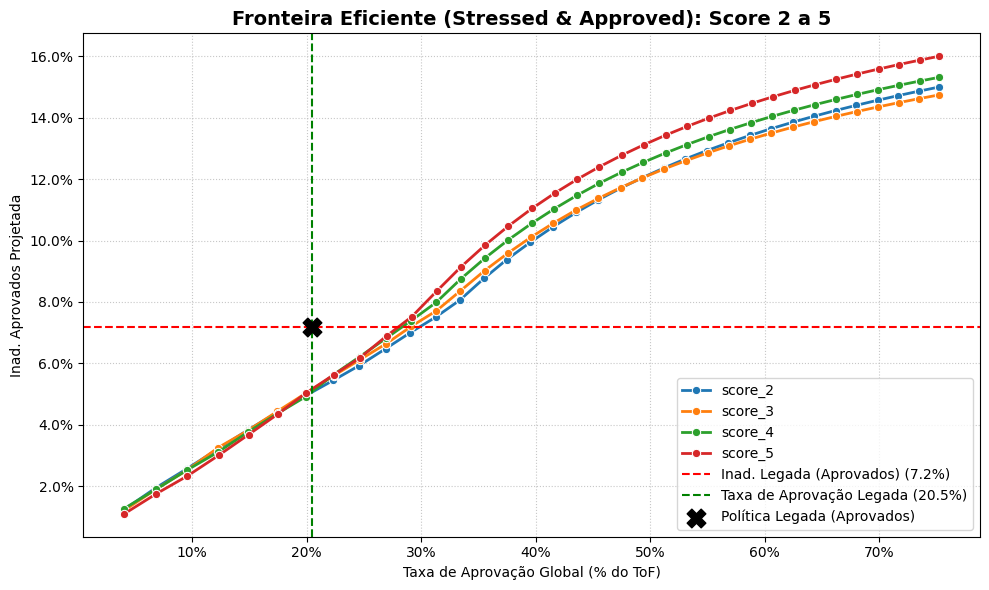

In [6]:
# Fator de agravamento base para o estresse dos Swap Ins (definido uma única vez)
AGRAVAMENTO_BASE = 1.2

def angulado_tradeoff(df_swap, pd_col):
    return (df_swap[pd_col] * AGRAVAMENTO_BASE).clip(0, 1)

policy_tradeoff = policy_hf.add_stress(CustomStress(angulado_tradeoff))

# Mantemos a grade de busca entre o percentil 5 e 95 dos aprovados da policy_hf
# para maior densidade de pontos próximos ao breakeven
cutoffs = (
    np.linspace(df_clean_hf["score_5"].quantile(0.05), df_clean_hf["score_5"].quantile(0.95), 35)
    .astype(int)
    .tolist()
)

# Nova API: Otimização com optimize_cutoffs
opt_results = {}
res_list = []

for i in range(2, 6):
    s_col = f"score_{i}"
    config_cand = CreditPolicy(
        applicant_id_col="applicant_id",
        score_cols=[s_col],
        current_approval_col="approved",
        actual_default_col="actual_default",
        time_col="safra"
    )
    # Copia etapas rígidas de entrada da policy_tradeoff
    for s in policy_tradeoff.stages:
        config_cand = config_cand.filter(s.name, s.condition)
    config_cand = config_cand.add_stress(CustomStress(angulado_tradeoff))
    
    # Executa a busca em grade com o novo argumento 'cutoff_ranges'
    opt_res = optimize_cutoffs(
        data=df_dev,
        config=config_cand,
        cutoff_ranges={s_col: cutoffs},
        target_default_rate=bad_hired,
        min_approval_rate=0.05,
        method="analytical"
    )
    opt_results[s_col] = opt_res
    
    # Mantém compatibilidade de colunas com as próximas células do notebook
    r = opt_res.all_results.copy()
    r["Score_Model"] = s_col
    r["approval_rate"] = r["overall_approval_rate"]
    r["default_rate"] = r["overall_default_rate"]
    r["Cutoff"] = r[s_col]
    res_list.append(r)

res_all = pd.concat(res_list)

# Exibimos as curvas completas de tradeoffs de todos os modelos comparados
# exatamente como no notebook V14 original (onde fica muito claro o ganho do Score 5)
from pycreditools.visualization import plot_tradeoffs

plot_tradeoffs(
    res_all,
    legacy_approval_rate=n_aprov / N,
    legacy_bad_rate=bad_hired,
    title="Fronteira Eficiente (Stressed & Approved): Score 2 a 5",
    hue_col="Score_Model",
    save_path="images/tradeoff_comparativo.png",
)
plt.show()

## 5. As 3 Proposições Executivas (Score 5)
Três estratégias de apetite ao risco baseadas no P&L Contratado Estressado.


=== AS 3 PROPOSIÇÕES EXECUTIVAS ===
Cenário              Cutoff   Aprov. Global  Inad. Contratada
────────────────────────────────────────────────────────────
1. Conservadora         796          19.90%             5.03%
2. Agressiva            719          26.98%             6.90%
3. Neutra               770          22.35%             5.63%
────────────────────────────────────────────────────────────
Legacy (referência)        ─          20.47%             7.18%


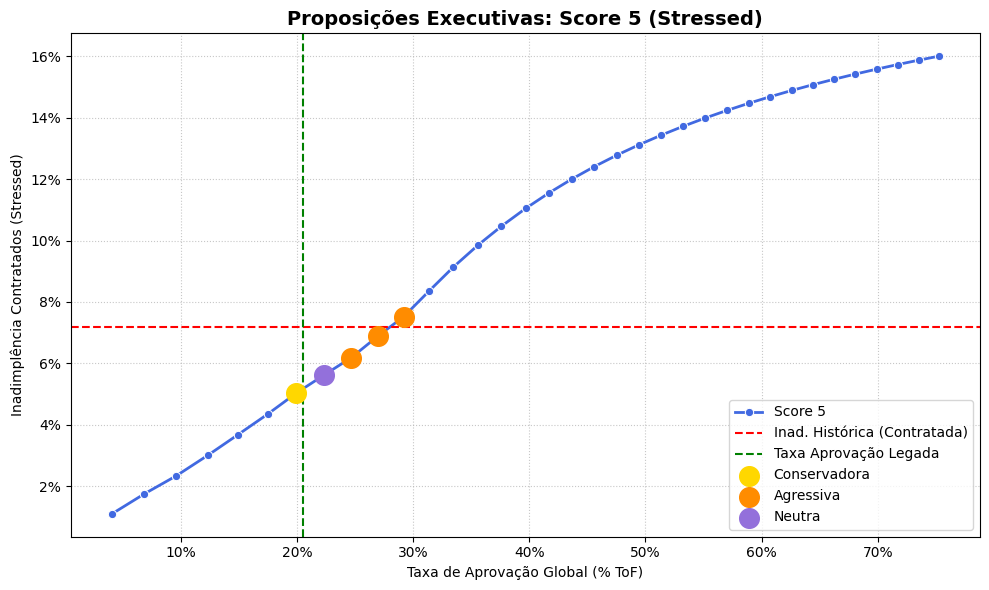


✓ Decisão do Comitê: Estratégia Conservadora → Cutoff Global = 796


In [7]:
# Prepara DataFrame para compatibilidade das variáveis e gráficos da célula
res_s5 = res_all[res_all["Score_Model"] == "score_5"].copy()
res_s5_opt = opt_results["score_5"]

# Nova API: Localizando políticas equivalentes usando find_equivalent
# 1. Conservadora: Mantém a taxa de aprovação da carteira legada (~20.5% do ToF)
pol_cons = res_s5_opt.find_equivalent(target_metric="approval_rate", target_value=n_aprov / N)
# 2. Agressiva: Mantém a taxa de inadimplência contratada do legado (~7.18%) sob estresse
pol_agr = res_s5_opt.find_equivalent(target_metric="default_rate", target_value=bad_hired)

# Ajusta variáveis de compatibilidade para o restante do notebook
pol_cons["approval_rate"] = pol_cons["overall_approval_rate"]
pol_cons["default_rate"] = pol_cons["overall_default_rate"]
pol_cons["Cutoff"] = pol_cons["score_5"]

pol_agr["approval_rate"] = pol_agr["overall_approval_rate"]
pol_agr["default_rate"] = pol_agr["overall_default_rate"]
pol_agr["Cutoff"] = pol_agr["score_5"]

mid_cut = (pol_cons["Cutoff"].iloc[0] + pol_agr["Cutoff"].iloc[0]) / 2
pol_mid = res_s5.iloc[(res_s5["Cutoff"] - mid_cut).abs().argsort()[:1]]

CUTOFF_GLOBAL = int(pol_cons["Cutoff"].iloc[0])

header = f"{'Cenário':<18} {'Cutoff':>8} {'Aprov. Global':>15} {'Inad. Contratada':>17}"
print("=== AS 3 PROPOSIÇÕES EXECUTIVAS ===")
print(header)
print("─" * 60)
for label, pol in [
    ("1. Conservadora", pol_cons),
    ("2. Agressiva", pol_agr),
    ("3. Neutra", pol_mid),
]:
    print(
        f"{label:<18} {int(pol['Cutoff'].iloc[0]):>8} "
        f"{pol['approval_rate'].iloc[0]:>15.2%} {pol['default_rate'].iloc[0]:>17.2%}"
    )
print(f"{'─' * 60}")
print(f"{'Legacy (referência)':<18} {'─':>8} {n_aprov / N:>15.2%} {bad_hired:>17.2%}")

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=res_s5,
    x="approval_rate",
    y="default_rate",
    marker="o",
    linewidth=2,
    color="royalblue",
    label="Score 5",
)
plt.axhline(
    y=bad_hired, color="r", linestyle="--", linewidth=1.5, label="Inad. Histórica (Contratada)"
)
plt.axvline(x=n_aprov / N, color="g", linestyle="--", linewidth=1.5, label="Taxa Aprovação Legada")
for label, pol, cor in [
    ("Conservadora", pol_cons, "gold"),
    ("Agressiva", pol_agr, "darkorange"),
    ("Neutra", pol_mid, "mediumpurple"),
]:
    plt.scatter(pol["approval_rate"], pol["default_rate"], color=cor, s=200, zorder=6, label=label)
plt.title("Proposições Executivas: Score 5 (Stressed)", fontsize=14, fontweight="bold")
plt.xlabel("Taxa de Aprovação Global (% ToF)")
plt.ylabel("Inadimplência Contratados (Stressed)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("images/tradeoff_individual.png", dpi=150)
plt.show()
print(f"\n✓ Decisão do Comitê: Estratégia Conservadora → Cutoff Global = {CUTOFF_GLOBAL}")

## 6. Adequação dos Pontos de Corte por Loja (Inadimplência Plana) e Política Final
Em vez de mantermos a taxa de aprovação constante (~20% por região) e permitir oscilações descontroladas de inadimplência regional (ex: Nordeste vs Sul), adotamos uma estratégia de **Inadimplência Plana** (Flat Default Rate). 

Definimos um alvo regionalizado baseado na PD Estressada da estratégia selecionada (Conservadora), permitindo que a taxa de aprovação local se ajuste dinamicamente conforme a qualidade do crédito de cada região.

Para realizar a calibração de forma metodologicamente correta e evitar dependência circular (os ratings dependem dos sobreviventes da simulação, e os simulated defaults estressados dependem dos ratings), realizamos o processo na seguinte ordem sequencial:
1. **Busca Programática de Cutoffs**: Determinamos as notas de corte de score por loja usando um cenário de estresse de referência estável e independente de ratings (fator multiplicativo estável de referência para todos os Swap Ins, idêntico ao da curva de tradeoff).
2. **Definição da Política Final**: Montamos a política de limites regionalizada baseada em score e simulamos as aprovações sem estresse para obter a população de aprovados sobreviventes.



In [8]:
# Otimização por Loja usando a API de find_optimal_cutoffs sobre cada região
def stress_referencia(df_swap, pd_col):
    return (df_swap[pd_col] * AGRAVAMENTO_BASE).clip(0, 1)

def calcular_take_up(df_in):
    # Calcula decis de score_5 dinamicamente no applicant dataframe
    deciles = pd.qcut(df_in["score_5"], q=10, labels=False, duplicates="drop")
    return 0.95 - deciles * 0.06

target_pd = float(pol_cons["default_rate"].iloc[0])
cutoffs_loja = {}

print(
    f"Buscando pontos de corte por loja para PD Estressada Plana de {target_pd:.2%} usando find_optimal_cutoffs..."
)
for loja in sorted(df_dev["region"].unique()):
    df_loja = df_dev[df_dev["region"] == loja].copy()
    
    # Configura a política para a loja (score_5)
    policy_cand = (
        CreditPolicy(
            applicant_id_col="applicant_id",
            score_cols=["score_5"],
            current_approval_col="approved",
            actual_default_col="actual_default",
            time_col="safra"
        )
    )
    # Copia etapas rígidas de entrada da policy_hf
    for s in policy_hf.stages:
        policy_cand = policy_cand.filter(s.name, s.condition)
    policy_cand = policy_cand.rate(
        "Propensão de Contrato", base_rate=1.0, variable=calcular_take_up
    )
    policy_cand = policy_cand.add_stress(CustomStress(stress_referencia))
    
    # Otimiza o cutoff usando a API do pacote (busca em grade de 150 pontos para alta precisão)
    opt_loja = optimize_cutoffs(
        data=df_loja,
        config=policy_cand,
        cutoff_steps=150,
        target_default_rate=target_pd,
        min_approval_rate=0.01,
        method="analytical"
    )
    
    cutoffs_loja[loja] = int(opt_loja.best_combination["score_5"])

print(f"\n=== PONTOS DE CORTE POR LOJA (INADIMPLÊNCIA PLANA ALVO {target_pd:.2%}) ===")
print(f"{'Loja':<15} {'Cutoff':>8}  {'Aprov. Local':>15}  {'PD Estressada (Ref)':>20}")
print("─" * 68)

def politica_loja(df_in):
    passa = pd.Series(False, index=df_in.index)
    for loja, cut in cutoffs_loja.items():
        passa.loc[(df_in["region"] == loja) & (df_in["score_5"] >= cut)] = True
    return passa

policy_final = policy_hf.filter("Score Regionalizado Flat PD", politica_loja).rate(
    "Propensão de Contrato", base_rate=1.0, variable=calcular_take_up
)
sim_final = policy_final.simulate(df)
res_final = sim_final.data

# Mostrar resultados por loja sob o estresse de referência
policy_final_ref = policy_final.add_stress(CustomStress(stress_referencia))
res_final_ref_dev = policy_final_ref.simulate(df_dev).data

for loja, cut in sorted(cutoffs_loja.items()):
    df_res_loja = res_final_ref_dev[res_final_ref_dev["region"] == loja]
    aprov_rate = df_res_loja["approved_pre_rate"].mean()
    n_hired = df_res_loja["new_approval"].sum()
    avg_pd = (
        (df_res_loja["simulated_default"] * df_res_loja["new_approval"]).sum() / n_hired
        if n_hired > 0
        else 0.0
    )
    print(f"{loja:<15} {int(cut):>8,}  {aprov_rate:>15.2%}  {avg_pd:>20.2%}")

Buscando pontos de corte por loja para PD Estressada Plana de 5.03% usando find_optimal_cutoffs...



=== PONTOS DE CORTE POR LOJA (INADIMPLÊNCIA PLANA ALVO 5.03%) ===
Loja              Cutoff     Aprov. Local   PD Estressada (Ref)
────────────────────────────────────────────────────────────────────


Centro-Oeste         820           16.86%                 4.73%
Nordeste             828           14.95%                 4.81%
Norte                815           15.85%                 4.98%


Sudeste              795           20.71%                 5.04%
Sul                  791           21.89%                 5.09%


## 7. Segmentação de Risco (Ward Clustering nos Sobreviventes)
Agora que a política de cortes está definida, treinamos a segmentação de risco (Ratings A a E) **diretamente sobre a população aprovada sobrevivente**. 

Isso garante que os Ratings reflitam a real distribuição de risco da carteira aprovada, evitando Ratings vazios e o clássico viés de encolhimento/truncamento temporal (eliminando cruzamentos e inversões de risco entre as safras).


=== VALIDAÇÃO DO CLUSTERING E ESTABILIDADE (NOVA API) ===
 risk_rating  volume       pd period
           1    9674 0.008270  Train
           2   14006 0.029844  Train
           3   16861 0.053556  Train
           4   16329 0.078021  Train
           5   14027 0.096813  Train
           1    4500 0.009111    OOT
           2    6510 0.027189    OOT
           3    8075 0.052632    OOT
           4    7723 0.083128    OOT
           5    6815 0.097139    OOT


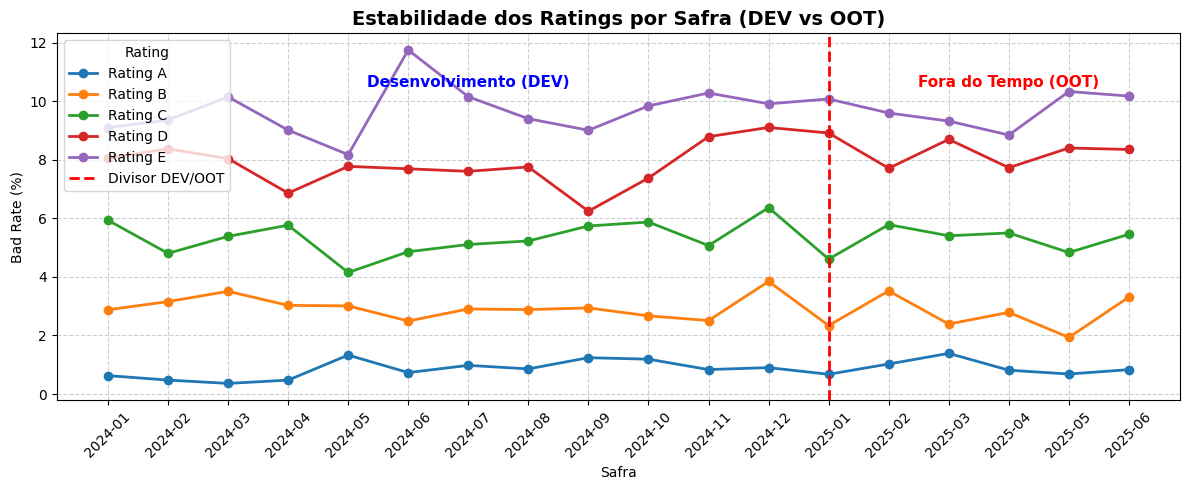

In [9]:
# Nova API: fit_risk_groups com partição automática de OOT e relatório de estabilidade
# Passamos todos os aprovados sobreviventes (DEV + OOT) e informamos o oot_date
df_survivors = res_final[res_final["new_approval"] > 0.0].copy()

group_res = fit_risk_groups(
    data=df_survivors,
    score_cols="score_5",
    default_col="actual_default",
    bins=30,
    max_groups=5,
    min_vol_ratio=0.01,
    method="ward",
    time_col="safra",
    max_crossings=1,
    oot_date="2025-01" # Nova feature de partição longitudinal do R
)

print("=== VALIDAÇÃO DO CLUSTERING E ESTABILIDADE (NOVA API) ===")
print(group_res.report.to_string(index=False))

LABELS = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}

# Mantendo 'Rating' no DataFrame para compatibilidade com gráficos/tabelas legados
pred_df = group_res.predict(df)
df["Rating"] = pred_df["risk_rating"].map(LABELS)

pred_res = group_res.predict(res_final)
res_final["Rating"] = pred_res["risk_rating"].map(LABELS)

# Estabilidade por Safra na população sobrevivente
from pycreditools.visualization import plot_vintage_stability
plot_vintage_stability(
    res_final,
    rating_col="Rating",
    time_col="safra",
    default_col="actual_default",
    approval_col="new_approval",
    oot_start_safra="2025-01",
    save_path="images/vintage_stability.png",
)
plt.show()

### 7b. Comparação Pareada de Ratings (Novas APIs)
Aproveitando que temos múltiplos scores candidates, comparamos os grupos de risco de forma pareada usando `fit_pairwise_risk_groups` para verificar o alinhamento com a nova política.


In [10]:
# Nova API: fit_pairwise_risk_groups comparando Score 5 (primary) contra score_4 e score_3 (challengers)
print("=== COMPARAÇÃO PAREADA DE RISK GROUPS (CHALLENGERS) ===")
pairwise_res = fit_pairwise_risk_groups(
    data=df_survivors,
    primary_score="score_5",
    challenger_scores=["score_4", "score_3"],
    default_col="actual_default",
    time_col="safra",
    bins=30,
    max_groups=5,
    oot_date="2025-01"
)

for key, pair_opt in pairwise_res.items():
    print(f"\nResultados para o par {key}:")
    print(pair_opt.report.head(10).to_string(index=False))


=== COMPARAÇÃO PAREADA DE RISK GROUPS (CHALLENGERS) ===



Resultados para o par score_5_vs_score_4:
 risk_rating  volume       pd period
         1.0   18230 0.009764  Train
         2.0   14234 0.035268  Train
         3.0   12690 0.057998  Train
         4.0   18353 0.089631  Train
         5.0    7390 0.131529  Train
         1.0    8631 0.019696    OOT
         2.0    6658 0.044908    OOT
         3.0    5945 0.061901    OOT
         4.0    8869 0.085353    OOT
         5.0    3513 0.100484    OOT

Resultados para o par score_5_vs_score_3:
 risk_rating  volume       pd period
         1.0   15828 0.007961  Train
         2.0   19194 0.035271  Train
         3.0   10425 0.060528  Train
         4.0   15444 0.087736  Train
         5.0   10006 0.124325  Train
         1.0    7408 0.020248    OOT
         2.0    9041 0.039708    OOT
         3.0    4995 0.067868    OOT
         4.0    7284 0.079489    OOT
         5.0    4877 0.106623    OOT


## 8. A Política Magnum: Simulação com Agravamento Swap In


In [11]:
# Agravamento Angulado Swap In ancorado no AGRAVAMENTO_BASE
def angulado(df_swap, pd_col):
    mapa = {
        "A": AGRAVAMENTO_BASE,
        "B": AGRAVAMENTO_BASE + 0.1,
        "C": AGRAVAMENTO_BASE + 0.2,
        "D": AGRAVAMENTO_BASE + 0.2,
        "E": AGRAVAMENTO_BASE + 0.3
    }
    fator = df_swap["Rating"].map(mapa).fillna(AGRAVAMENTO_BASE + 0.2)
    return (df_swap[pd_col] * fator).clip(0,1)

policy_magnum = (
    policy_final
    .add_stress(CustomStress(angulado))
)

sim_magnum = policy_magnum.simulate(df)
res_final_mag = sim_magnum.data
res_final_mag["hired_sim"] = res_final_mag["new_approval"]

aprov_nova_pct = (res_final_mag["approved_pre_rate"] > 0).sum() / N
print(f"✓ Aprovação global nova política: {aprov_nova_pct:.2%} (alvo ~{n_aprov/N:.2%})")



✓ Aprovação global nova política: 18.85% (alvo ~20.47%)


## 9. Dissecção dos Swaps: Quem Entra, Quem Sai
Calculamos a inadimplência observada real para o Swap Out baseado na performance histórica.


In [12]:
from pycreditools import (
    print_quadrant_summary,
    print_rating_quadrant_table,
    print_swap_in_by_rating,
)

# 1. Resumo dos Quadrantes
print_quadrant_summary(sim_magnum)

# 2. Raio-X dos Swap Ins por Rating
print_swap_in_by_rating(sim_magnum, rating_col="Rating")

# 3. Aprovados e Contratados por Rating e Quadrante
print_rating_quadrant_table(sim_magnum, rating_col="Rating")

=== QUADRANTES: VOLUME ESPERADO CONTRATADO E INADIMPLÊNCIA ===
Quadrante      Vol. Contratado      Bad Rate  Fonte
─────────────────────────────────────────────────────────────────
Keep In                 64,933         4.21%  actual_default (observado)
Swap In                 18,474         9.46%  simulated_default (agravado/simulado)
Swap Out                29,742        13.68%  actual_default (observado na carteira antiga)
Keep Out                     0           N/A  sem dados (reprovados por ambas)



=== RAIO-X DOS SWAP INS POR RATING ===
  Rating   Vol. Esperado    Vol %   Inad Stressed
──────────────────────────────────────────────────
       E           6,744    36.5%          12.64%
       D           5,820    31.5%           9.72%
       C           3,763    20.4%           7.07%
       B           1,506     8.2%           3.74%
       A             642     3.5%           1.18%



=== APROVADOS E CONTRATADOS POR RATING E QUADRANTE ===


Rating scenario  Aprovados Contratados Bad_Rate
     E  keep_in      14775       7,145    8.31%
     E keep_out          0           0      N/A
     E  swap_in      13697       6,744   12.64%
     E swap_out      47078      25,839   14.41%
     D  keep_in      24664      11,670    6.83%
     D keep_out          0           0      N/A
     D  swap_in      12382       5,820    9.72%
     D swap_out       2249       1,064   12.88%
     C  keep_in      36960      16,667    4.79%
     C keep_out          0           0      N/A
     C  swap_in       8269       3,763    7.07%
     C swap_out       2731       1,263   10.06%
     B  keep_in      41652      16,843    2.58%
     B keep_out          0           0      N/A
     B  swap_in       3673       1,506    3.74%
     B swap_out       2543       1,047    6.97%
     A  keep_in      30816      12,608    0.86%
     A keep_out          0           0      N/A
     A  swap_in       1566         642    1.18%
     A swap_out       1278         529  

## 10. Tabela Delta: Impacto P&L Executivo


In [13]:
from pycreditools import print_delta_table
print_delta_table(sim_magnum)



=== TABELA DELTA: P&L EXECUTIVO ===
Métrica                                 Legacy        Nova       Δ Abs       Δ Rel
──────────────────────────────────────────────────────────────────────────────
Aprovação Global (% ToF)                20.47%      18.85%      -1.63%       -8.0%
Bad Rate Contratado (P&L)                7.18%       5.37%      -1.81%      -25.2%
Vol. Contratado Esperado                94,675      83,407     -11,268      -11.9%


## 11. Crash Test: O Airbag do Swap In
Até que ponto a política é resiliente e qual o breakeven de estresse dos Swap Ins.


🔥 BREAKEVEN ENCONTRADO: Fator = 2.75×
   Bad Rate projetada: 7.24% (teto: 7.18%)
   → A PD real dos Swap Ins teria que ser 2.75× pior do que
     o nosso modelo estima para o P&L novo empatar com o legado.


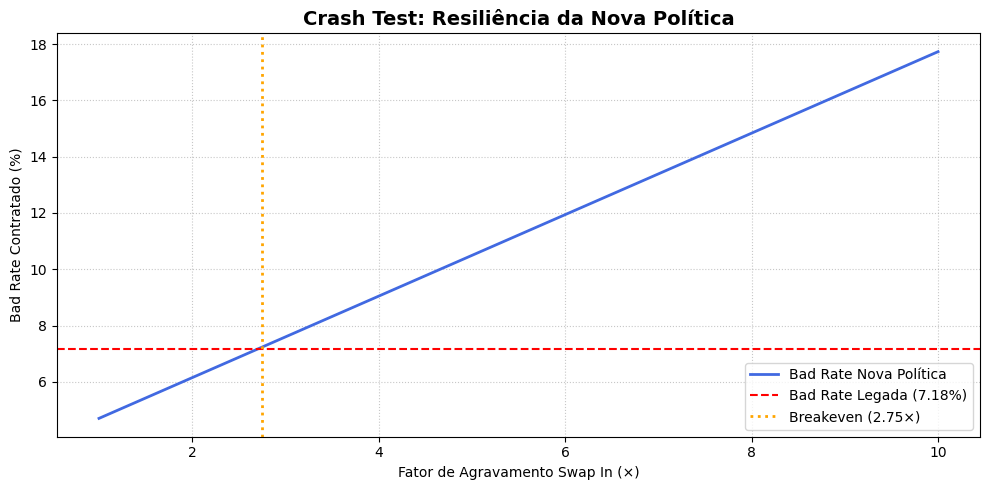

In [14]:
an_st = TradeoffAnalyzer(policy_final)
# Stress Swap In up to 10x to find the exact breakeven factor
an_st.vary_stress_aggravation(np.linspace(1.0, 10.0, 37).tolist())
res_st = an_st.run(df_dev, parallel=False)

breakeven = None
for _, row in res_st.iterrows():
    if row["default_rate"] >= bad_hired:
        breakeven = row["aggravation_factor"]
        print(f"🔥 BREAKEVEN ENCONTRADO: Fator = {breakeven:.2f}×")
        print(f"   Bad Rate projetada: {row['default_rate']:.2%} (teto: {bad_hired:.2%})")
        print(f"   → A PD real dos Swap Ins teria que ser {breakeven:.2f}× pior do que")
        print(f"     o nosso modelo estima para o P&L novo empatar com o legado.")
        break
if not breakeven:
    print("A nova política não regride mesmo com fator 10.0× no Swap In.")

from pycreditools.visualization import plot_crash_test
plot_crash_test(
    res_st,
    legacy_bad_rate=bad_hired,
    breakeven_factor=breakeven,
    save_path="images/crash_test.png"
)
plt.show()



## 12. Exportação de Política e Geração de Base Simplificada para Produção
Como etapa final, exportamos toda a nossa inteligência de decisão (filtros hard, pontos de corte regionalizados e regras de Ratings de risco) para um único arquivo JSON.

Em produção, carregamos esse arquivo e executamos decisões limpas para novos proponentes, gerando uma base simplificada com apenas os inputs originais mais a decisão consolidada (`decisao` e `motivo` da reprovação por ordem de ocorrência no funil) e o `rating` de risco.


In [15]:
from pycreditools import DeploymentPolicy

# 1. Export the final policy (clean production rules, omitting study metadata and conversions)
dep_policy = policy_final.export(
    path="politica_final_producao.json",
    clean=True # New feature: exports only raw decision rules (filters and cutoffs)!
)
print("✓ Final policy successfully exported to 'politica_final_producao.json'!")

# 1.5. Display the clean structure of the generated JSON file
print("\n=== EXPORTED JSON STRUCTURE (PRODUCTION RULES - CLEAN WITH FUNNEL STAGES) ===")
with open("politica_final_producao.json", encoding="utf-8") as f:
    print(f.read())

# 2. Load the exported policy (simulating deployment/production environment)
dep_loaded = DeploymentPolicy.load("politica_final_producao.json")

# 3. Apply the loaded policy on a test sample to get the clean decision DataFrame
df_amostra = df_dev.sample(10, random_state=42).copy()
df_decisoes = dep_loaded.predict(df_amostra, simple=True)

print("\n=== SIMPLIFIED DECISION DATAFRAME FOR PRODUCTION (SAMPLE) ===")
cols_show = [
    c for c in [
        "applicant_id",
        "region",
        "score_5",
        "age",
        "vl_negativacao",
        "decision",
        "reason",
        "hired",
        "defaulted",
        "scenario",
        "rating",
    ]
    if c in df_decisoes.columns
]
print(df_decisoes[cols_show].to_string(index=False))

✓ Final policy successfully exported to 'politica_final_producao.json'!

=== EXPORTED JSON STRUCTURE (PRODUCTION RULES - CLEAN WITH FUNNEL STAGES) ===
{
    "funnel_stages": [
        {
            "position": 1,
            "name": "CPF Válido",
            "type": "filter",
            "expression": "(cpf_valido == True)"
        },
        {
            "position": 2,
            "name": "Teto Negativação",
            "type": "filter",
            "expression": "(vl_negativacao <= 1500)"
        },
        {
            "position": 3,
            "name": "Teto Atraso SCR",
            "type": "filter",
            "expression": "(vl_vencido_scr <= 3000)"
        },
        {
            "position": 4,
            "name": "Teto Protestos",
            "type": "filter",
            "expression": "(vl_protestos <= 500)"
        },
        {
            "position": 5,
            "name": "Score Regionalizado Flat PD",
            "type": "filter",
            "expression": "callable:po